In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter

sns.set_theme(style="whitegrid")
sns.set_context("paper", font_scale=1.2)
plt.rcParams['figure.dpi'] = 300 # Alta resolução para impressão
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['pdf.fonttype'] = 42 # Evita fontes rasterizadas em PDFs

strategy_palette = {"zero-shot": "#1b9e77", "few-shot": "#d95f02", "chain-of-thought": "#7570b3"}

In [46]:
wcag_guidelines = [
    "1.1.1", 
    "1.2.1", "1.2.2", "1.2.3", "1.2.4", "1.2.5", "1.2.6", "1.2.7", "1.2.8", "1.2.9",
    "1.3.1", "1.3.2", "1.3.3", "1.3.4", "1.3.5", "1.3.6",
    "1.4.1", "1.4.2", "1.4.3", "1.4.4", "1.4.5", "1.4.6", "1.4.7", "1.4.8", "1.4.9", "1.4.10", "1.4.11", "1.4.12", "1.4.13",

    "2.1.1", "2.1.2", "2.1.3", "2.1.4",
    "2.2.1", "2.2.2", "2.2.3", "2.2.4", "2.2.5", "2.2.6",
    "2.3.1", "2.3.2", "2.3.3",
    "2.4.1", "2.4.2", "2.4.3", "2.4.4", "2.4.5", "2.4.6", "2.4.7", "2.4.8", "2.4.9", "2.4.10", "2.4.11", "2.4.12", "2.4.13",
    "2.5.1", "2.5.2", "2.5.3", "2.5.4", "2.5.5", "2.5.6", "2.5.7", "2.5.8",

    "3.1.1", "3.1.2", "3.1.3", "3.1.4", "3.1.5", "3.1.6",
    "3.2.1", "3.2.2", "3.2.3", "3.2.4", "3.2.5", "3.2.6",
    "3.3.1", "3.3.2", "3.3.3", "3.3.4", "3.3.5", "3.3.6", "3.3.7", "3.3.8", "3.3.9",

    "4.1.1", "4.1.2", "4.1.3"
]

In [47]:
ARQUIVO_RESULTADOS = "./experiment_results/metrics_output_final.csv"
ARQUIVO_LINHAS_ERRO = "./experiment_results/dropped_items_limitations.csv"
ARQUIVO_DATASET = "Original_full_data_new.csv"

In [48]:
resultados = pd.read_csv(ARQUIVO_RESULTADOS)
linhas_error = list(pd.read_csv(ARQUIVO_LINHAS_ERRO)["failed_item_id"])

In [49]:
resultados['temp_model'] = resultados['model'].apply(lambda m: m.replace('google/', ''))

In [50]:
total_linhas = len(resultados["item_id"].unique())

print(f"Total de linhas por experimento: {total_linhas}")
print(f"Linhas com error: {len(linhas_error)}")

Total de linhas por experimento: 3524
Linhas com error: 111


# Top 10 violações reais encontradas

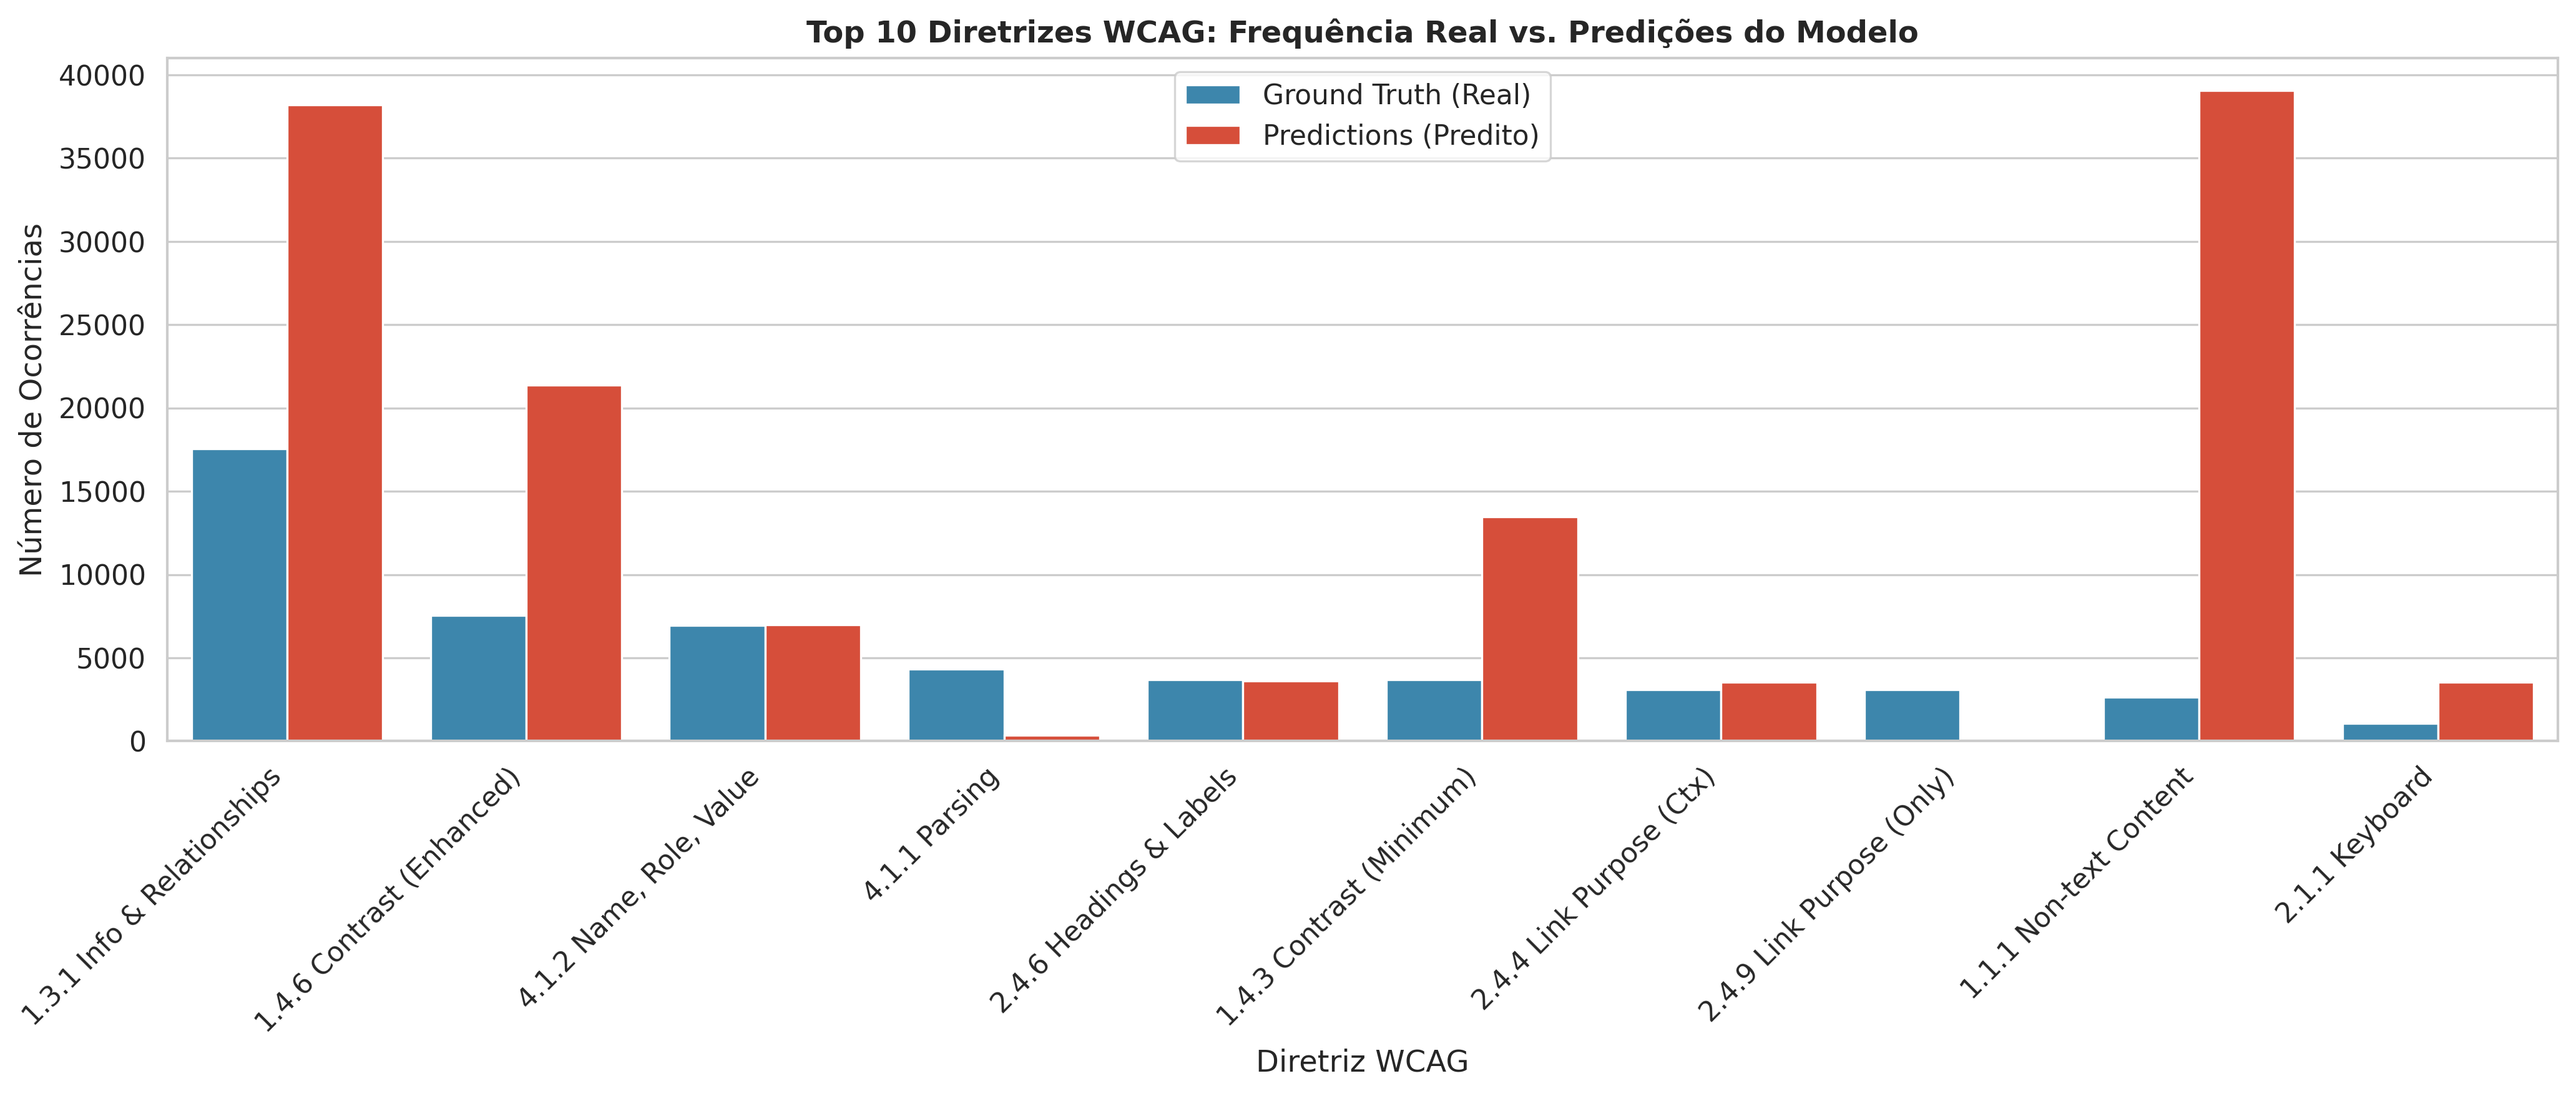

In [51]:
# Função segura para explodir as strings separadas por pipe (|)
import re
def parse_codes(val):
    pattern = r"\b[1-4]\.\d+\.\d+\b"
    matches = re.findall(pattern, str(val))
    return set(matches)

wcag_names_map = {
    "1.3.1": "1.3.1 Info & Relationships",
    "1.4.6": "1.4.6 Contrast (Enhanced)",
    "4.1.2": "4.1.2 Name, Role, Value",
    "4.1.1": "4.1.1 Parsing",
    "2.4.6": "2.4.6 Headings & Labels",
    "1.4.3": "1.4.3 Contrast (Minimum)",
    "2.4.4": "2.4.4 Link Purpose (Ctx)",
    "2.4.9": "2.4.9 Link Purpose (Only)",
    "1.1.1": "1.1.1 Non-text Content",
    "2.1.1": "2.1.1 Keyboard"
}

# Extrai todas as listas de códigos
resultados['gt_list'] = resultados['ground_truth'].apply(parse_codes)
resultados['pred_list'] = resultados['predictions'].apply(parse_codes)

# Conta as frequências globais no dataset
gt_counts = Counter([code for sublist in resultados['gt_list'] for code in sublist])
pred_counts = Counter([code for sublist in resultados['pred_list'] for code in sublist])

# Converte para DataFrame para facilitar a plotagem
df_freq = pd.DataFrame({
    'Ground Truth (Real)': pd.Series(gt_counts),
    'Predictions (Predito)': pd.Series(pred_counts)
}).fillna(0).astype(int)

# Seleciona as Top 10 violações mais frequentes no Ground Truth
top10_classes = df_freq.sort_values(by='Ground Truth (Real)', ascending=False).head(10).index
df_top10 = df_freq.loc[top10_classes].reset_index().rename(columns={'index': 'WCAG Guideline'})
df_top10['WCAG Guideline'] = df_top10['WCAG Guideline'].map(lambda x: wcag_names_map.get(x, x))

# 2. Continua com o código que você já tinha...
df_top10_melted = df_top10.melt(id_vars='WCAG Guideline', var_name='Origem', value_name='Frequência')

# Plotagem
plt.figure(figsize=(14, 6)) # Aumentei um pouco a largura para acomodar os textos maiores
sns.barplot(
    data=df_top10_melted, 
    x='WCAG Guideline', 
    y='Frequência', 
    hue='Origem', 
    palette=['#2b8cbe', '#f03b20']
)

plt.title('Top 10 Diretrizes WCAG: Frequência Real vs. Predições do Modelo', fontweight='bold')
plt.xlabel('Diretriz WCAG')
plt.ylabel('Número de Ocorrências')
plt.legend(title='')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Top 10 violações preditas mais encontradas

In [52]:
experimentos = pd.read_csv("./experiment_results/metrics_output_final.csv")
experimentos['temp_model'] = experimentos['model'].apply(lambda m: m.replace('google/', ''))

experimentos["ground_truth"] = experimentos["ground_truth"].fillna("").apply(
    lambda x: x.split("|") if x else []
)


In [53]:
lista = set()
algo = list(experimentos['ground_truth'])
for i in algo:
    for j in i:
        lista.add(j)
lista

{'1.1.1',
 '1.2.2',
 '1.3.1',
 '1.3.5',
 '1.4.1',
 '1.4.12',
 '1.4.2',
 '1.4.3',
 '1.4.4',
 '1.4.6',
 '2.1.1',
 '2.2.1',
 '2.4.1',
 '2.4.10',
 '2.4.2',
 '2.4.3',
 '2.4.4',
 '2.4.6',
 '2.4.9',
 '2.5.3',
 '2.5.5',
 '3.1.1',
 '3.1.2',
 '3.3.2',
 '4.1.1',
 '4.1.2'}

In [54]:
df_freq_1 = df_freq.reset_index()
clean_df = df_freq_1[~df_freq_1['index'].isin(wcag_guidelines)].copy()

In [55]:
clean_df

,index,Ground Truth (Real),Predictions (Predito)
0,1.0.0,0,1
1,1.0.3,0,1
2,1.028.774,0,1
4,1.1.10,0,1
5,1.1.100,0,1
...,...,...,...
21172,4.99.5,0,1
21173,4.99.6,0,1
21174,4.99.7,0,1
21175,4.99.8,0,1


In [ ]:
experimentos["predictions"] = experimentos["predictions"].fillna("").apply(
    lambda x: x.split("|") if x else []
)
def contar_alucinacoes(lista)->int:
    count = 0
    for i in lista:
        if (i not in wcag_guidelines):
            count+=1
    return count

experimentos['num_alucinacoes'] = experimentos['predictions'].apply(contar_alucinacoes)
experimentos.groupby(['model', 'strategy'])[['num_alucinacoes']].sum().reset_index()

,model,strategy,num_alucinacoes
0,gemma-3-4b-it,chain-of-thought,1619
1,gemma-3-4b-it,few-shot,91189
2,gemma-3-4b-it,zero-shot,101933
3,google/gemma-4-e2b,chain-of-thought,81
4,google/gemma-4-e2b,few-shot,107
5,google/gemma-4-e2b,zero-shot,106
6,google/gemma-4-e4b,chain-of-thought,56
7,google/gemma-4-e4b,few-shot,63
8,google/gemma-4-e4b,zero-shot,51
9,qwen3-1.7b,chain-of-thought,5614


In [56]:
len(wcag_guidelines)

87

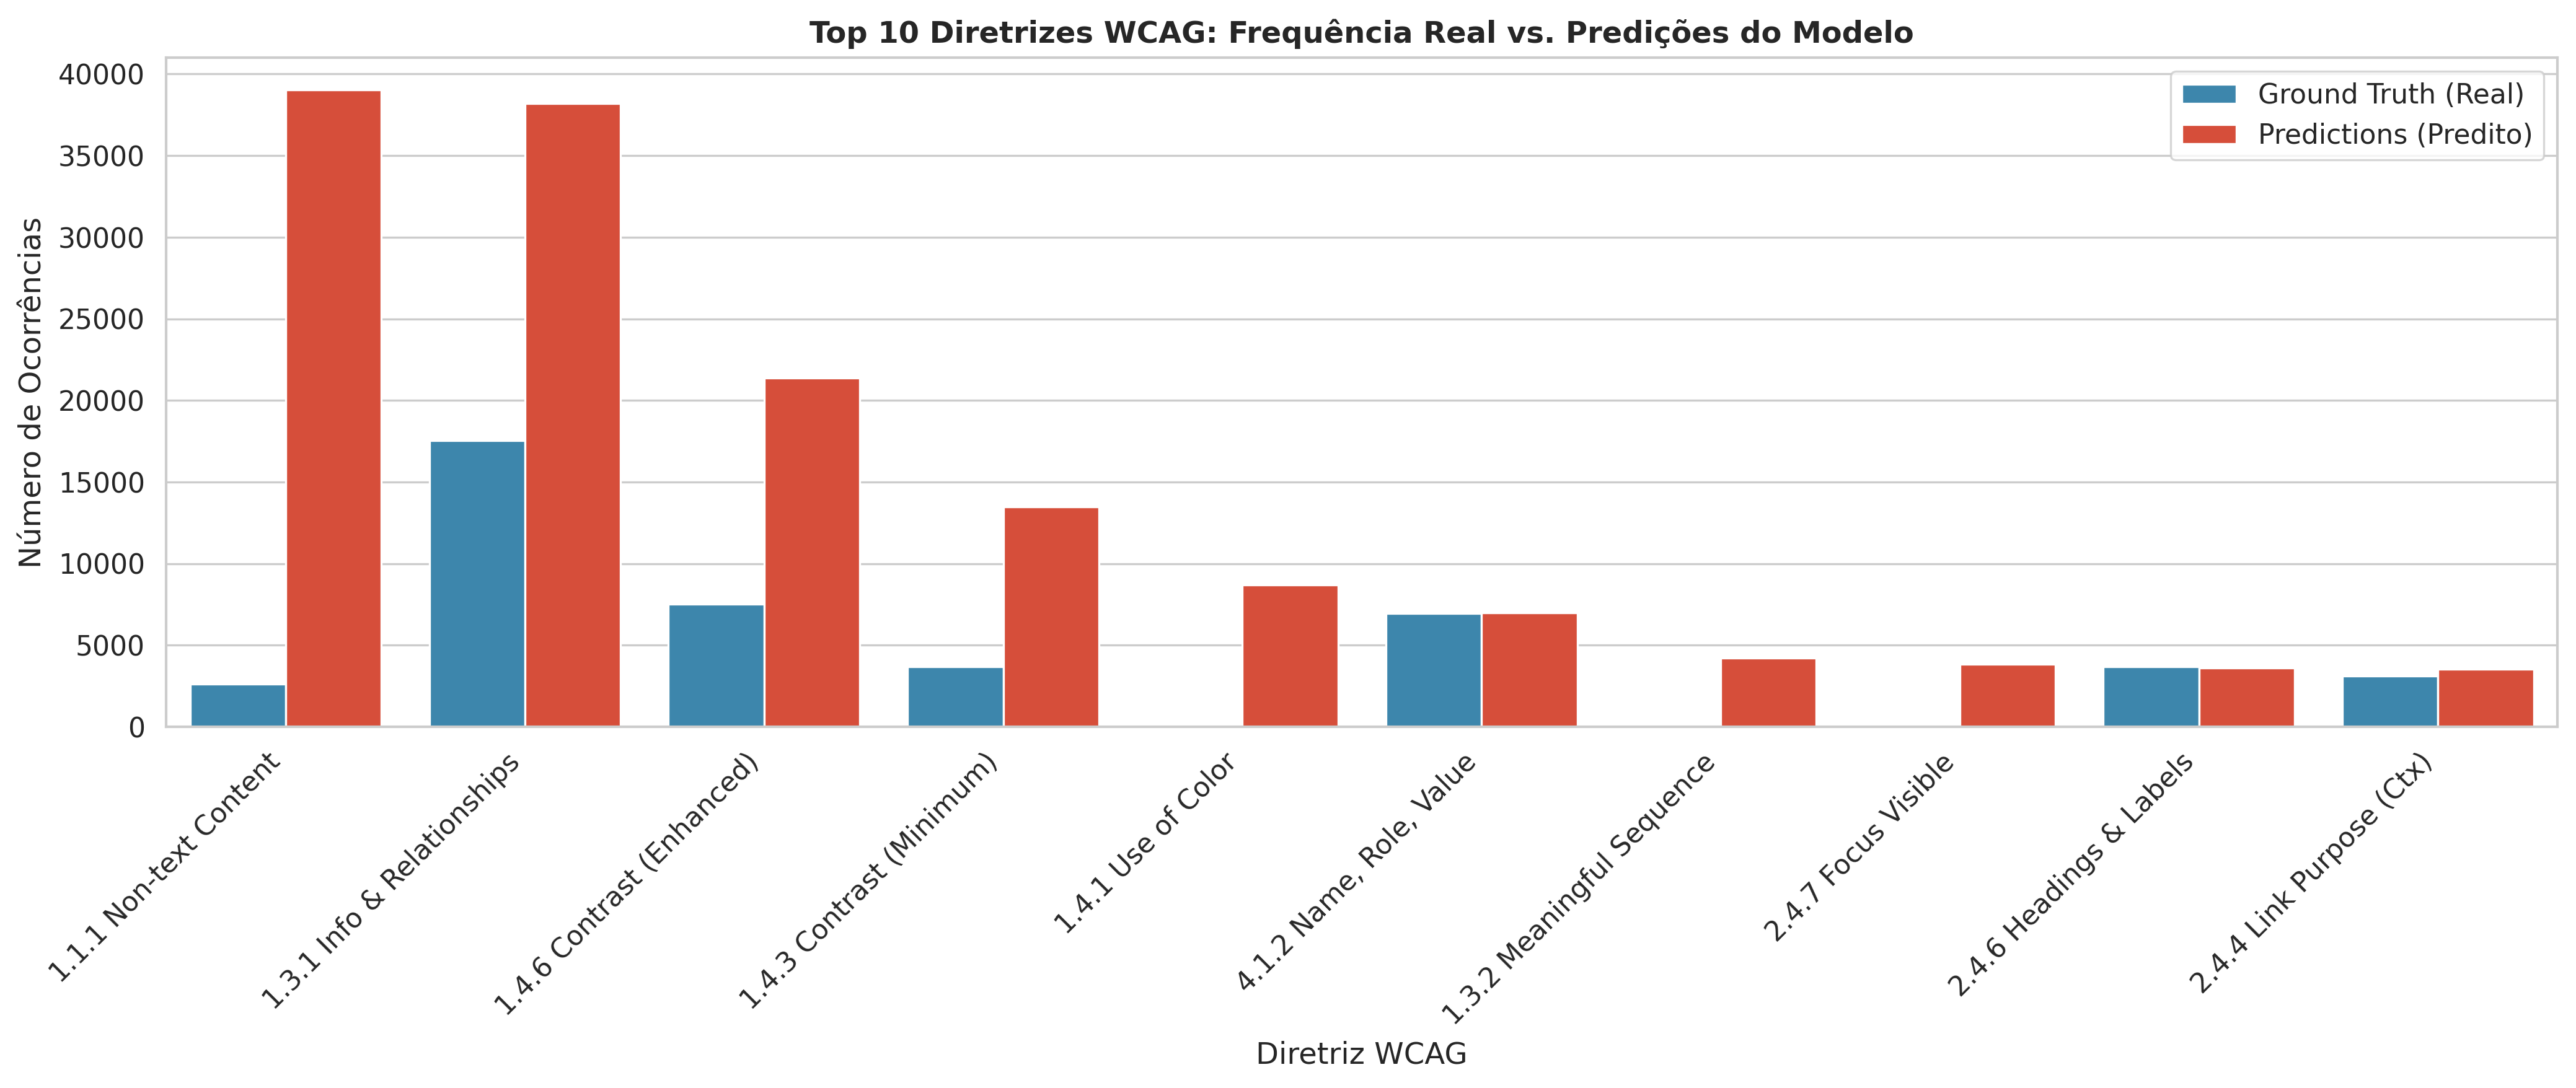

In [57]:
wcag_names_map = {
    "1.1.1": "1.1.1 Non-text Content",
    "1.3.1": "1.3.1 Info & Relationships",
    "1.4.6": "1.4.6 Contrast (Enhanced)",
    "1.4.3": "1.4.3 Contrast (Minimum)",
    "1.4.1": "1.4.1 Use of Color",
    "4.1.2": "4.1.2 Name, Role, Value",
    "1.3.2": "1.3.2 Meaningful Sequence",
    "2.4.7": "2.4.7 Focus Visible",
    "2.4.6": "2.4.6 Headings & Labels",
    "2.4.4": "2.4.4 Link Purpose (Ctx)"
}

# Extrai todas as listas de códigos
resultados['gt_list'] = resultados['ground_truth'].apply(parse_codes)
resultados['pred_list'] = resultados['predictions'].apply(parse_codes)

# Conta as frequências globais no dataset
gt_counts = Counter([code for sublist in resultados['gt_list'] for code in sublist])
pred_counts = Counter([code for sublist in resultados['pred_list'] for code in sublist])

# Converte para DataFrame para facilitar a plotagem
df_freq = pd.DataFrame({
    'Ground Truth (Real)': pd.Series(gt_counts),
    'Predictions (Predito)': pd.Series(pred_counts)
}).fillna(0).astype(int)

# Seleciona as Top 10 violações mais frequentes no Predito
top10_classes = df_freq.sort_values(by='Predictions (Predito)', ascending=False).head(10).index
df_top10 = df_freq.loc[top10_classes].reset_index().rename(columns={'index': 'WCAG Guideline'})
df_top10['WCAG Guideline'] = df_top10['WCAG Guideline'].map(lambda x: wcag_names_map.get(x, x))

# 2. Continua com o código que você já tinha...
df_top10_melted = df_top10.melt(id_vars='WCAG Guideline', var_name='Origem', value_name='Frequência')

# Plotagem
plt.figure(figsize=(14, 6)) # Aumentei um pouco a largura para acomodar os textos maiores
sns.barplot(
    data=df_top10_melted, 
    x='WCAG Guideline', 
    y='Frequência', 
    hue='Origem', 
    palette=['#2b8cbe', '#f03b20']
)

plt.title('Top 10 Diretrizes WCAG: Frequência Real vs. Predições do Modelo', fontweight='bold')
plt.xlabel('Diretriz WCAG')
plt.ylabel('Número de Ocorrências')
plt.legend(title='')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

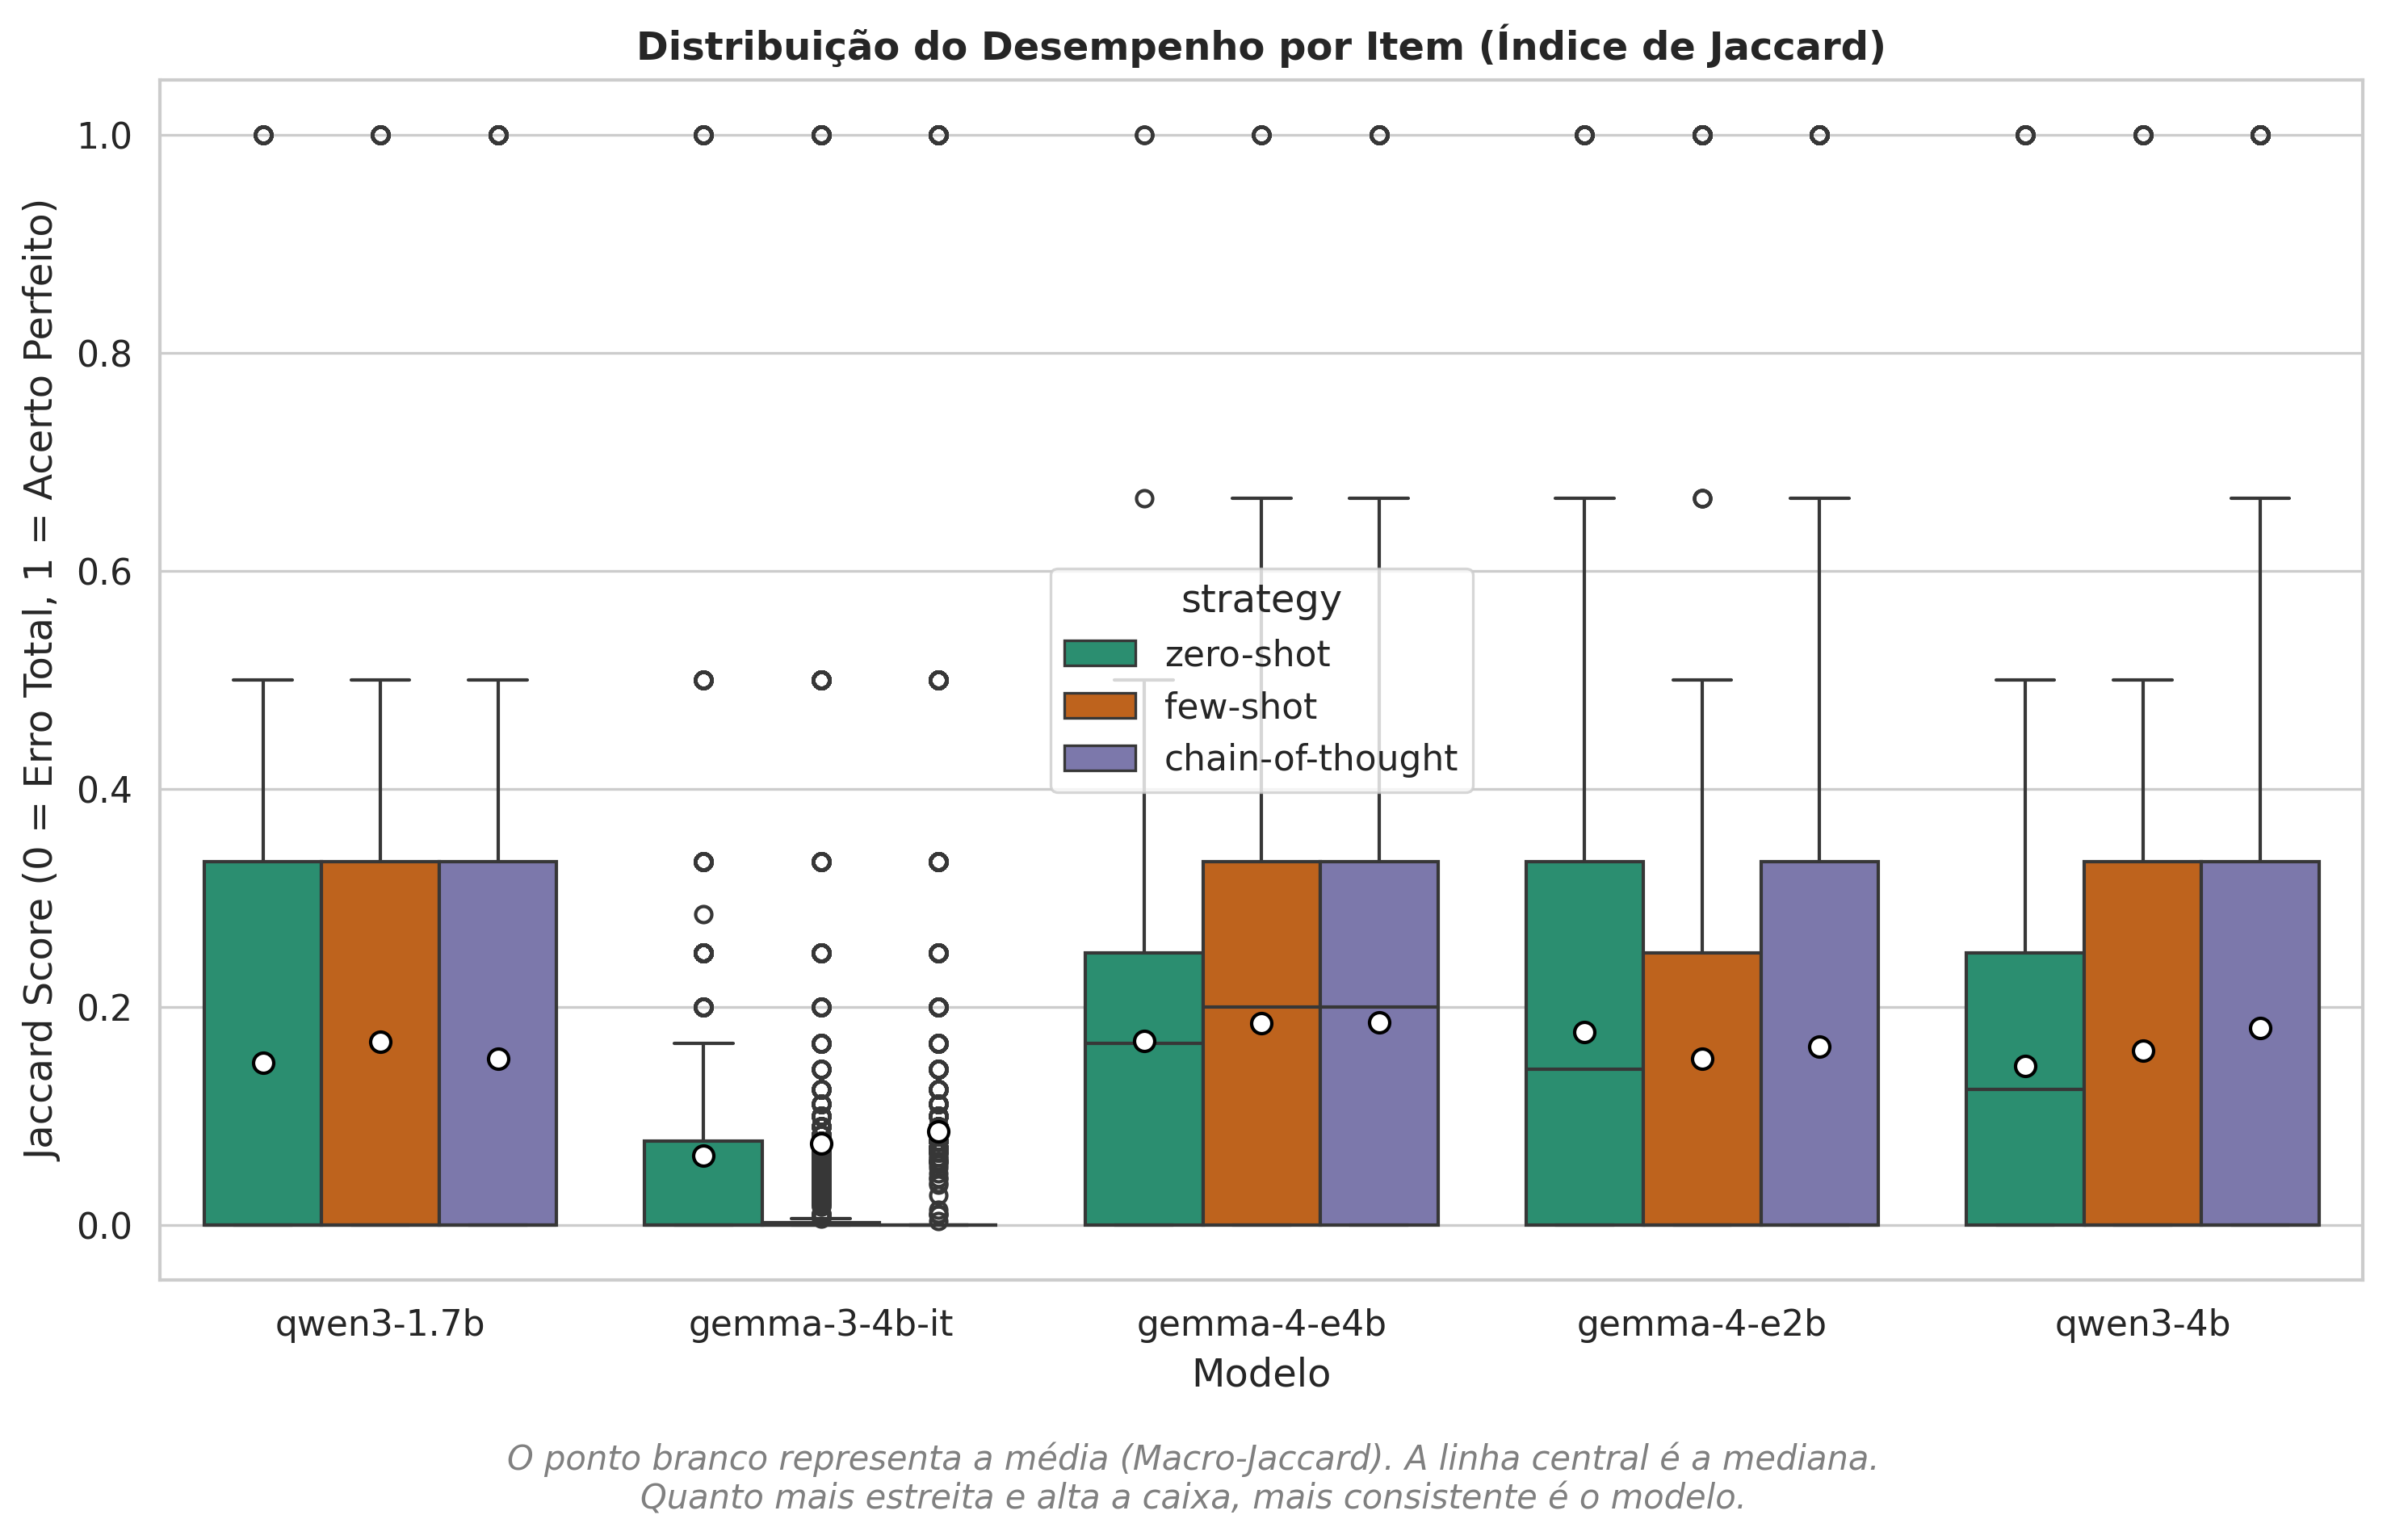

In [58]:
def calculate_jaccard(row):
    """
    Calcula a Interseção sobre União (IoU) dos códigos WCAG.
    1.0 = Acerto perfeito | 0.0 = Erro total
    """
    gt_set = set(row['gt_list'])
    pred_set = set(row['pred_list'])
    
    # Se ambos são vazios, o modelo acertou o Verdadeiro Negativo perfeitamente
    if not gt_set and not pred_set:
        return 1.0
    # Se um é vazio e o outro não, erro completo
    if not gt_set or not pred_set:
        return 0.0
        
    intersection = len(gt_set.intersection(pred_set))
    union = len(gt_set.union(pred_set))
    return intersection / union

# Calcula o score por item
resultados['jaccard_score'] = resultados.apply(calculate_jaccard, axis=1)


# Visualização da distribuição das notas via Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=resultados, 
    x='temp_model', 
    y='jaccard_score', 
    hue='strategy', 
    palette=strategy_palette,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"}
)

plt.title('Distribuição do Desempenho por Item (Índice de Jaccard)', fontweight='bold')
plt.ylabel('Jaccard Score (0 = Erro Total, 1 = Acerto Perfeito)')
plt.xlabel('Modelo')

# Adiciona uma explicação rápida para o artigo
plt.figtext(
    0.5, -0.05, 
    "O ponto branco representa a média (Macro-Jaccard). A linha central é a mediana.\nQuanto mais estreita e alta a caixa, mais consistente é o modelo.", 
    ha="center", fontsize=10, style='italic', color='gray'
)

plt.tight_layout()
plt.show()

In [59]:
from scipy.stats import friedmanchisquare, wilcoxon
import itertools

def analyze_strategy_differences(model_name):
    print(f"=== Análise Estatística Pareada para o Modelo: {model_name} ===")
    
    # Filtra os dados do modelo
    df_model = resultados[resultados['model'] == model_name]
    
    # Extrai as séries de Jaccard para cada estratégia
    # O sort_values garante que estamos alinhando os mesmos item_ids (medidas repetidas)
    zero_shot = df_model[df_model['strategy'] == 'zero-shot'].sort_values('item_id')['jaccard_score'].values
    few_shot = df_model[df_model['strategy'] == 'few-shot'].sort_values('item_id')['jaccard_score'].values
    cot = df_model[df_model['strategy'] == 'chain-of-thought'].sort_values('item_id')['jaccard_score'].values
    
    # 1. Teste de Friedman (Avalia se pelo menos UMA estratégia é estatisticamente diferente)
    # Requisito: Exatamente os mesmos itens em todas as arrays
    if not (len(zero_shot) == len(few_shot) == len(cot)):
        print("Aviso: Tamanho das amostras difere. Certifique-se de ter filtrado os itens com erro.")
        return
        
    stat, p_friedman = friedmanchisquare(zero_shot, few_shot, cot)
    
    print(f"Teste de Friedman | Estatística: {stat:.4f} | P-valor: {p_friedman:.4e}")
    
    if p_friedman >= 0.05:
        print("Conclusão Global: Não há diferença estatística entre as três estratégias de prompt.\n")
        return
        
    print("Conclusão Global: Há diferença significativa entre as estratégias. Executando testes pareados...\n")
    
    # 2. Testes Pairwise de Wilcoxon (Quem é melhor que quem?)
    strategies_data = {'zero-shot': zero_shot, 'few-shot': few_shot, 'chain-of-thought': cot}
    pairs = list(itertools.combinations(strategies_data.keys(), 2))
    
    # Correção de Bonferroni para múltiplos testes (alpha / 3 comparações)
    alpha_corrected = 0.05 / len(pairs)
    print(f"Nível de Significância com Correção de Bonferroni: {alpha_corrected:.4f}\n")
    
    for strat1, strat2 in pairs:
        # Wilcoxon compara a magnitude das diferenças pareadas
        w_stat, p_wilcoxon = wilcoxon(strategies_data[strat1], strategies_data[strat2], zero_method='zsplit')
        
        # Média para saber quem "ganhou"
        mean1 = strategies_data[strat1].mean()
        mean2 = strategies_data[strat2].mean()
        
        is_significant = p_wilcoxon < alpha_corrected
        
        winner = strat1 if mean1 > mean2 else strat2
        if not is_significant:
            winner = "Empate Técnico"
            
        print(f"Comparação: [{strat1}] vs [{strat2}]")
        print(f"  Médias: {strat1}={mean1:.4f} | {strat2}={mean2:.4f}")
        print(f"  P-valor: {p_wilcoxon:.4e} -> Significativo? {'SIM' if is_significant else 'NÃO'}")
        print(f"  Vencedor: {winner}\n")

# Executa para todos os modelos presentes no dataset
for model in resultados['model'].unique():
    analyze_strategy_differences(model)

=== Análise Estatística Pareada para o Modelo: qwen3-1.7b ===
Teste de Friedman | Estatística: 65.4655 | P-valor: 6.0863e-15
Conclusão Global: Há diferença significativa entre as estratégias. Executando testes pareados...

Nível de Significância com Correção de Bonferroni: 0.0167

Comparação: [zero-shot] vs [few-shot]
  Médias: zero-shot=0.1491 | few-shot=0.1685
  P-valor: 5.4829e-14 -> Significativo? SIM
  Vencedor: few-shot

Comparação: [zero-shot] vs [chain-of-thought]
  Médias: zero-shot=0.1491 | chain-of-thought=0.1529
  P-valor: 7.7227e-01 -> Significativo? NÃO
  Vencedor: Empate Técnico

Comparação: [few-shot] vs [chain-of-thought]
  Médias: few-shot=0.1685 | chain-of-thought=0.1529
  P-valor: 6.5660e-07 -> Significativo? SIM
  Vencedor: few-shot

=== Análise Estatística Pareada para o Modelo: gemma-3-4b-it ===
Teste de Friedman | Estatística: 2.5503 | P-valor: 2.7939e-01
Conclusão Global: Não há diferença estatística entre as três estratégias de prompt.

=== Análise Estatística

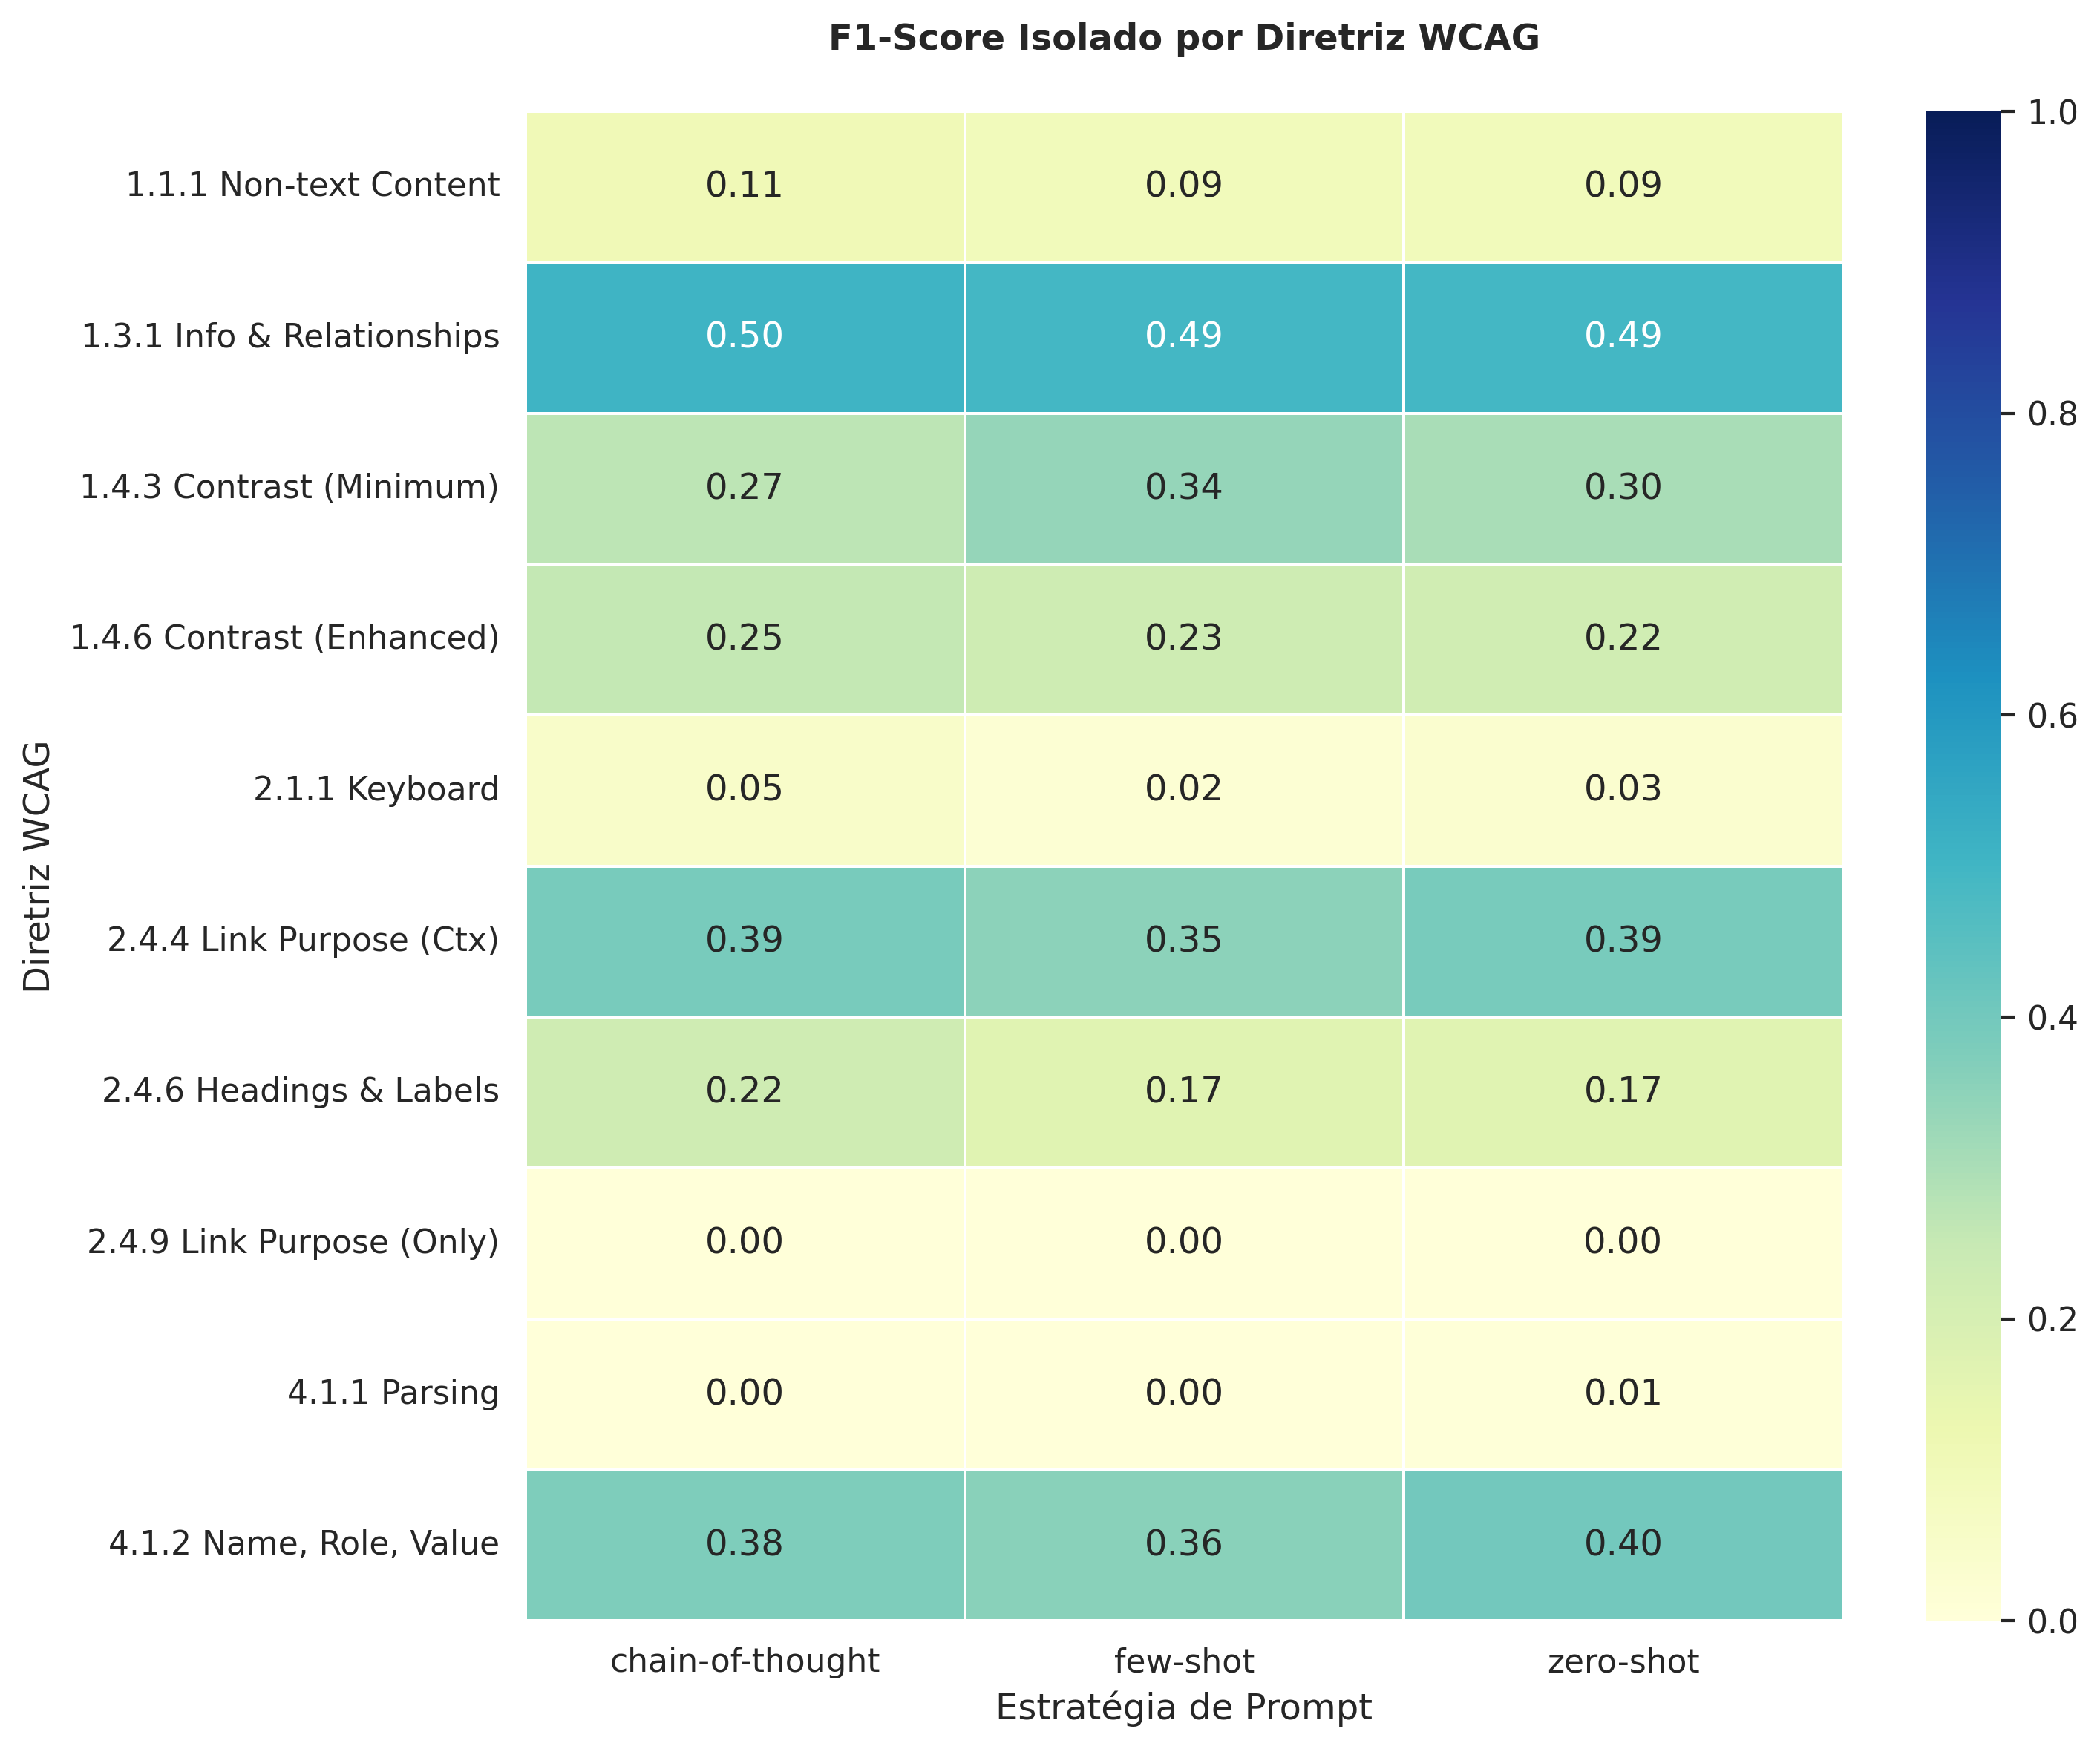

In [ ]:
top10_codes = df_freq.sort_values(by='Ground Truth (Real)', ascending=False).head(10).index.tolist()

wcag_names_map = {
    "1.3.1": "1.3.1 Info & Relationships",
    "1.4.6": "1.4.6 Contrast (Enhanced)",
    "4.1.2": "4.1.2 Name, Role, Value",
    "4.1.1": "4.1.1 Parsing",
    "2.4.6": "2.4.6 Headings & Labels",
    "1.4.3": "1.4.3 Contrast (Minimum)",
    "2.4.4": "2.4.4 Link Purpose (Ctx)",
    "2.4.9": "2.4.9 Link Purpose (Only)",
    "1.1.1": "1.1.1 Non-text Content",
    "2.1.1": "2.1.1 Keyboard"
}

# Estrutura para armazenar o F1-Score por diretriz
heatmap_data = []

df_target = resultados[resultados['model'] == "google/gemma-4-e4b"]

for strategy in df_target['strategy'].unique():
    df_strat = df_target[df_target['strategy'] == strategy]
    
    for code in top10_codes:
        # Calcular TP, FP e FN APENAS para esta diretriz específica
        tp = sum(df_strat.apply(lambda x: code in x['gt_list'] and code in x['pred_list'], axis=1))
        fp = sum(df_strat.apply(lambda x: code not in x['gt_list'] and code in x['pred_list'], axis=1))
        fn = sum(df_strat.apply(lambda x: code in x['gt_list'] and code not in x['pred_list'], axis=1))
        
        # F1-Score isolado
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
        
        heatmap_data.append({'Strategy': strategy, 'WCAG': wcag_names_map.get(code, code), 'F1-Score': f1})

df_heat = pd.DataFrame(heatmap_data).pivot(index='WCAG', columns='Strategy', values='F1-Score')

plt.figure(figsize=(10, 8))
sns.heatmap(df_heat, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5, vmin=0, vmax=1)

plt.title('F1-Score Isolado por Diretriz WCAG', fontweight='bold', pad=20)
plt.ylabel('Diretriz WCAG')
plt.xlabel('Estratégia de Prompt')

plt.tight_layout()
plt.show()

/tmp/ipykernel_19433/3619444196.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels([str(int(abs(tick))) for tick in ticks])


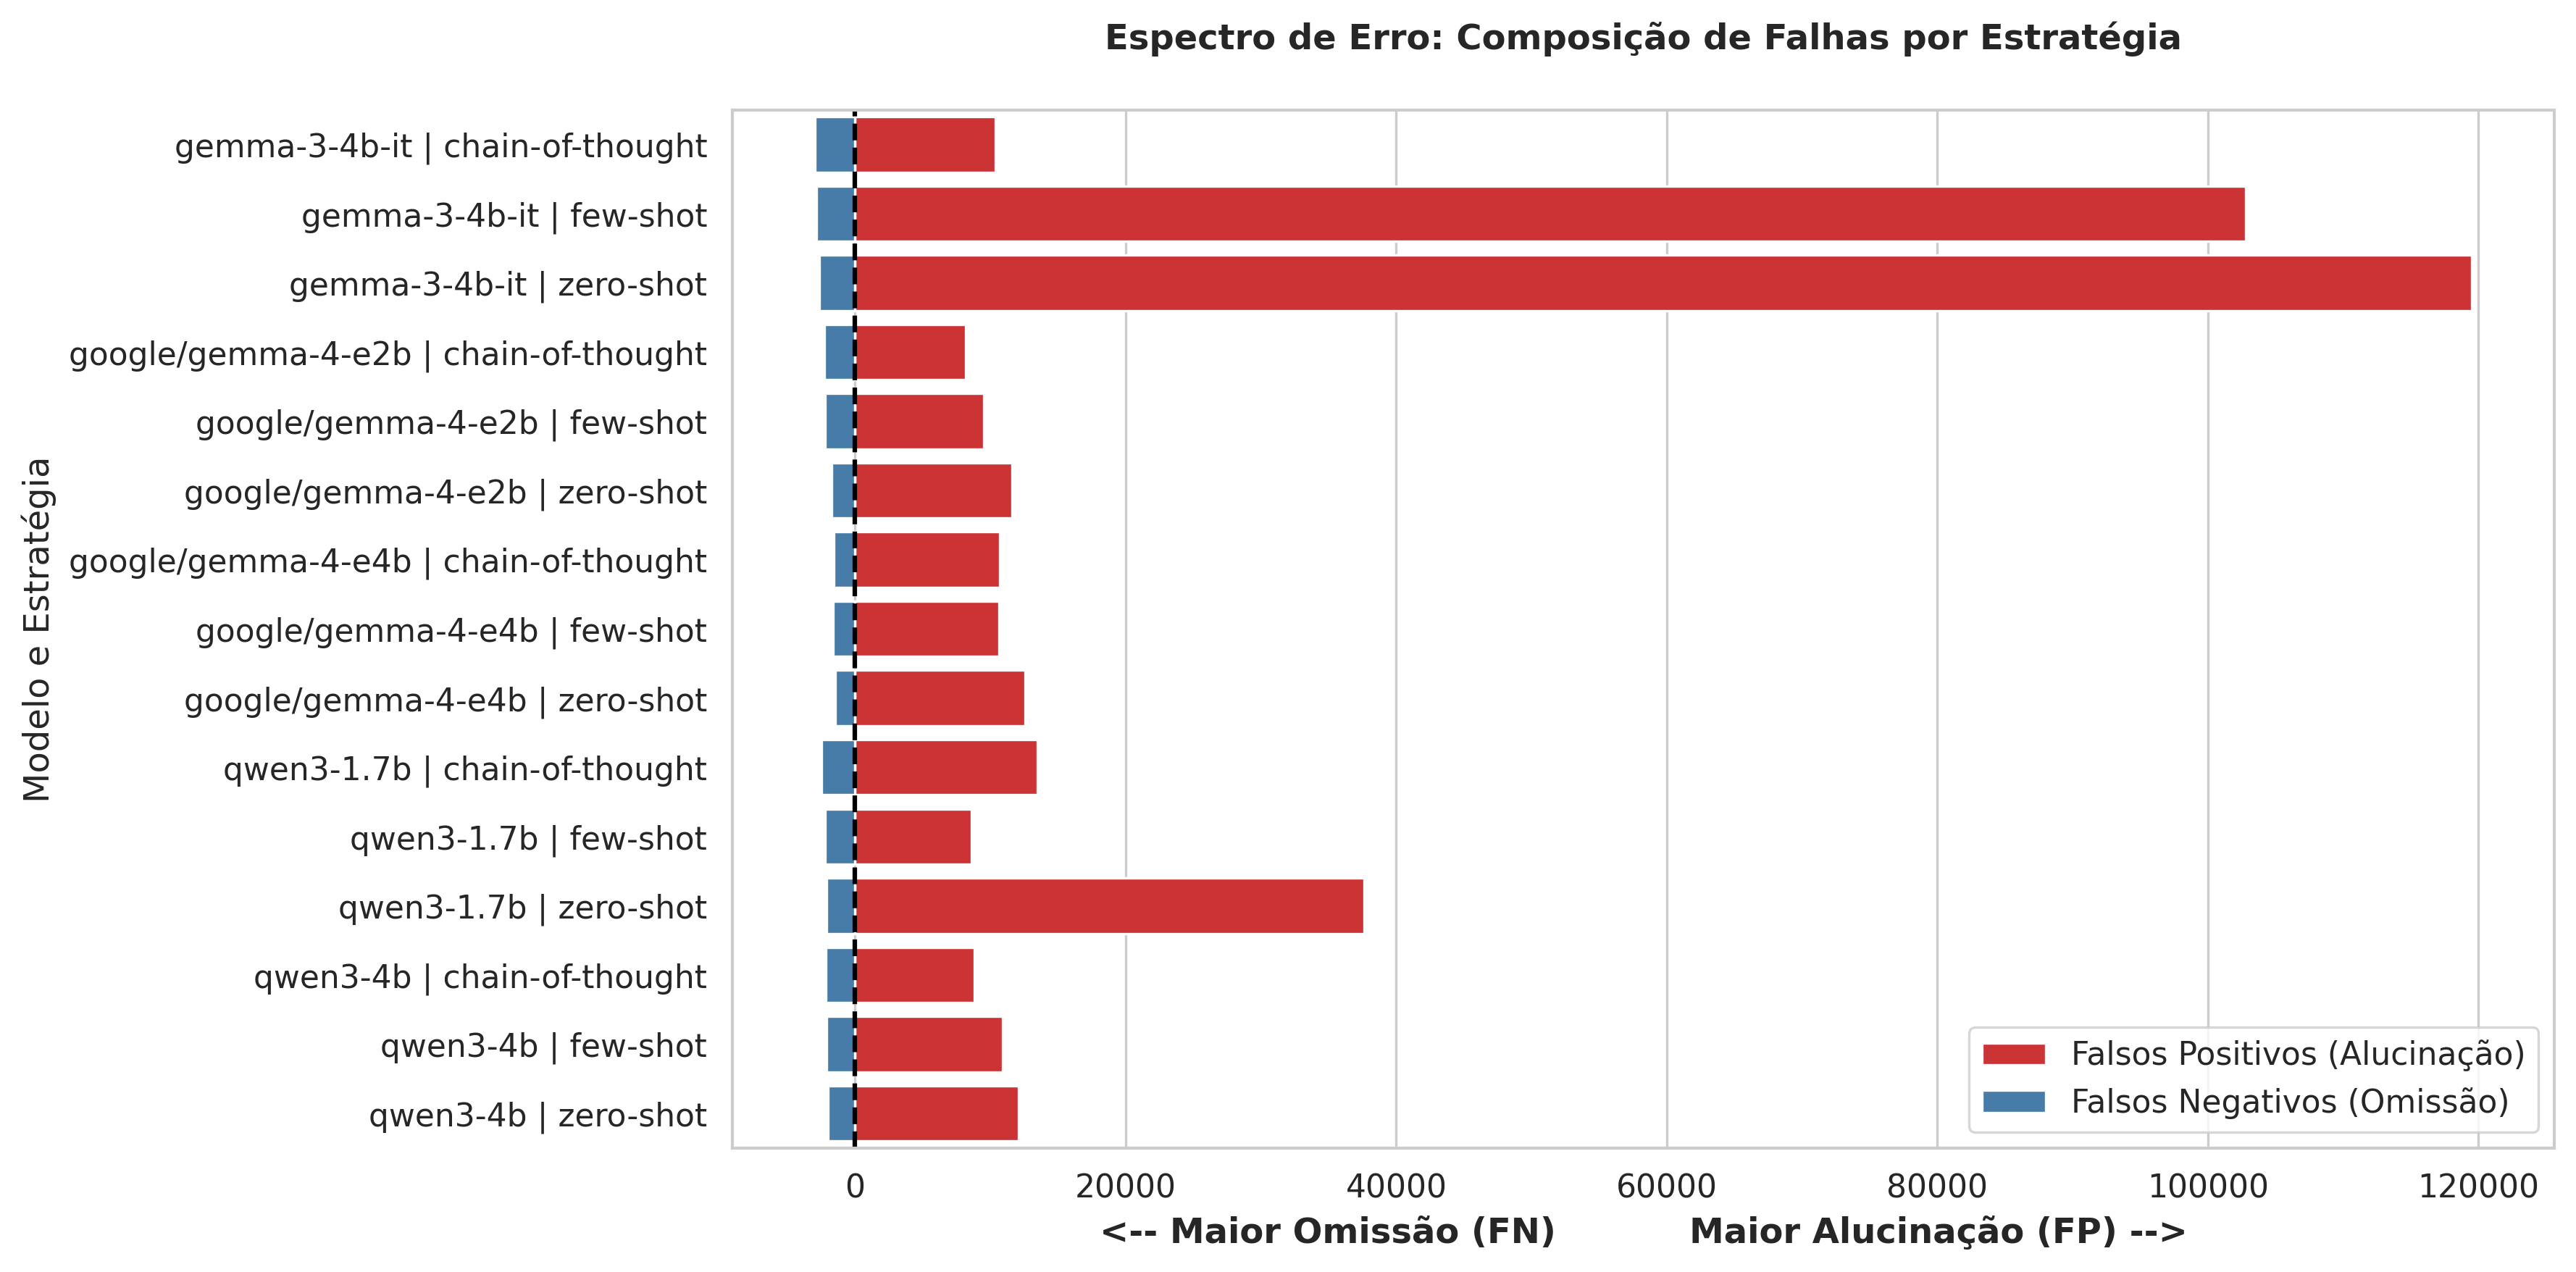

In [61]:
df_errors = resultados.groupby(['model', 'strategy'])[['fp', 'fn']].sum().reset_index()

# Criando um rótulo combinado para o eixo Y
df_errors['model_strat'] = df_errors['model'] + " | " + df_errors['strategy']

# Para criar o efeito divergente, transformamos FN em valores negativos
df_errors['fn_negative'] = df_errors['fn'] * -1

plt.figure(figsize=(12, 6))

# Plotando os Falsos Positivos (Direita / Vermelho)
sns.barplot(data=df_errors, x='fp', y='model_strat', color='#e41a1c', label='Falsos Positivos (Alucinação)')

# Plotando os Falsos Negativos (Esquerda / Azul)
sns.barplot(data=df_errors, x='fn_negative', y='model_strat', color='#377eb8', label='Falsos Negativos (Omissão)')

# Adicionando uma linha vertical no zero
plt.axvline(0, color='black', linewidth=1.5, linestyle='--')

plt.title('Espectro de Erro: Composição de Falhas por Estratégia', fontweight='bold', pad=20)
plt.xlabel('<-- Maior Omissão (FN)           Maior Alucinação (FP) -->', fontweight='bold')
plt.ylabel('Modelo e Estratégia')

# Ocultando os valores negativos no eixo X para não confundir o leitor
ticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([str(int(abs(tick))) for tick in ticks])

plt.legend(loc='lower right')
plt.tight_layout()

plt.show()

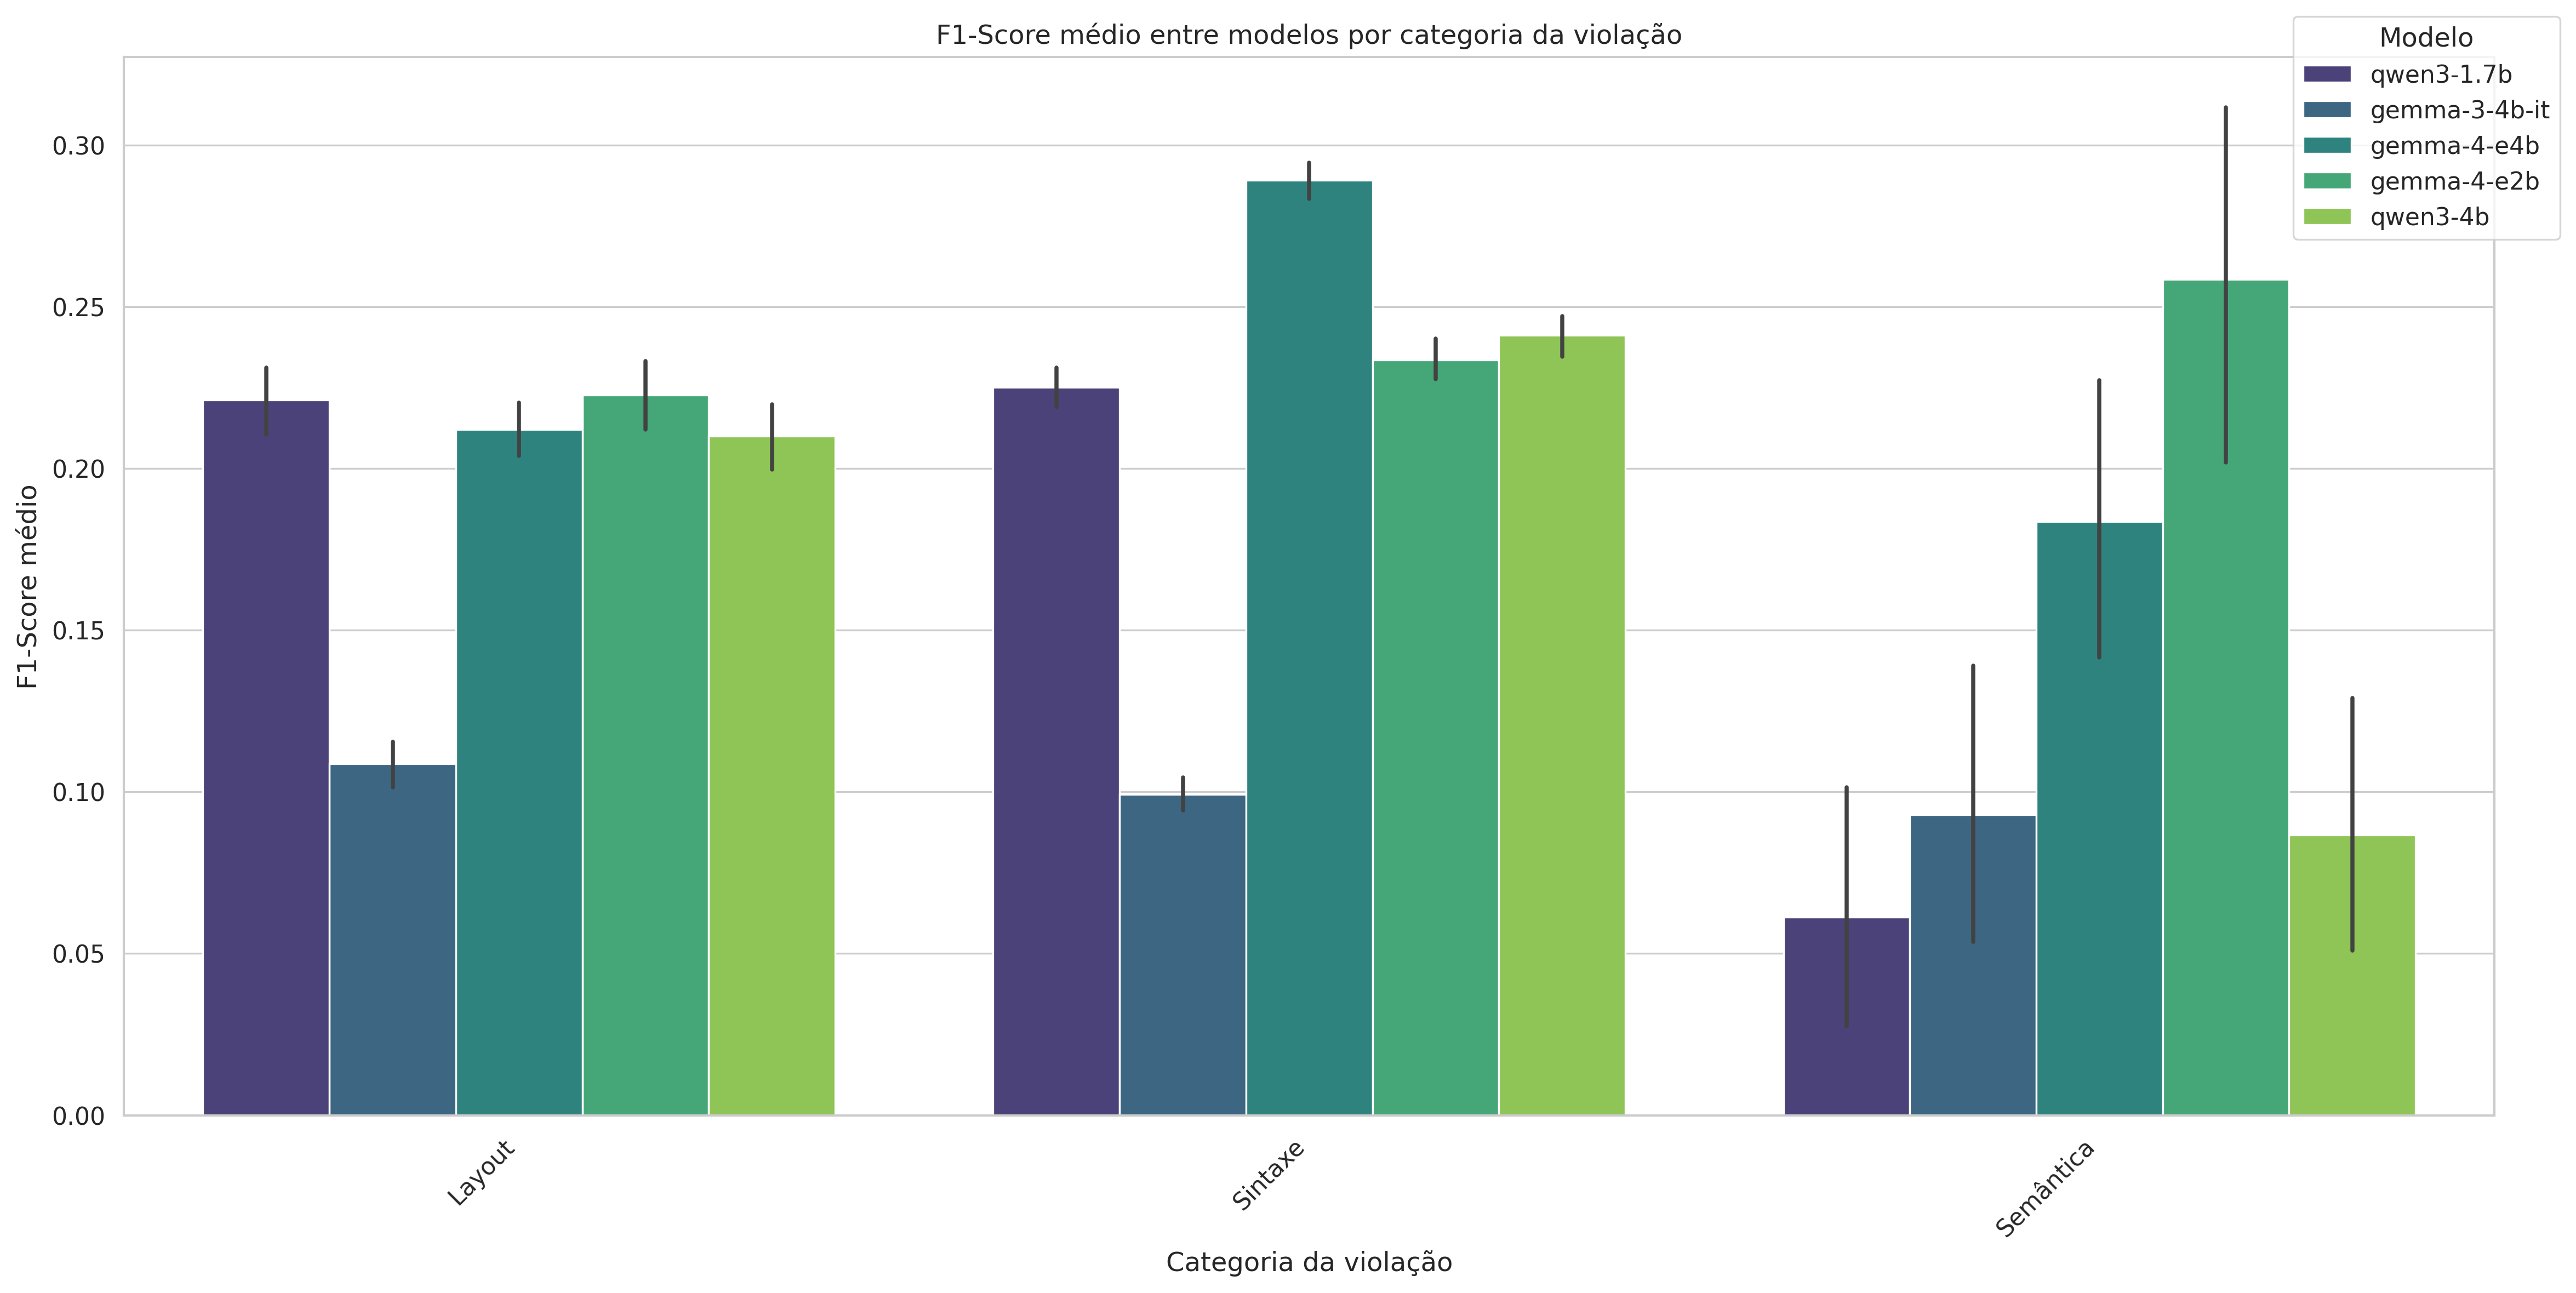

In [76]:
dataset = pd.read_csv(ARQUIVO_DATASET)
merged_df = pd.merge(dataset, experimentos, left_on='id', right_on='item_id', how='inner')
merged_df['violation_category_pt'] = merged_df['violation_category'].replace({
    'Layout': 'Layout',
    'Syntax': 'Sintaxe',
    'Semantic': 'Semântica'
})

plt.figure(figsize=(16, 8))
sns.barplot(data=merged_df, x='violation_category_pt', y='f1_score', hue='temp_model', palette='viridis')
plt.title('F1-Score médio entre modelos por categoria da violação')
plt.xlabel('Categoria da violação')
plt.ylabel('F1-Score médio')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Modelo', bbox_to_anchor=(0.91, 1.05), loc='upper left')
plt.tight_layout()
plt.show()